In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('perrin-freres-monthly-champagne-.csv')
df.head(5)

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [3]:
df.tail()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


# step 1 - cleaning data

In [5]:
df.columns=['Month','Sales']
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [6]:
# drop last two rows
df.drop(106,axis=0,inplace=True)

In [7]:
df.drop(105,axis=0,inplace=True)

In [8]:
df.tail()

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


In [9]:
# convert month column to datetime format from string
df['Month']=pd.to_datetime(df['Month'])

In [10]:
df.head()

,Month,Sales
0,1964-01-01,2815.0
1,1964-02-01,2672.0
2,1964-03-01,2755.0
3,1964-04-01,2721.0
4,1964-05-01,2946.0


In [11]:
df.set_index('Month',inplace=True)

In [12]:
df.head()

,Sales
Month,
1964-01-01,2815.0
1964-02-01,2672.0
1964-03-01,2755.0
1964-04-01,2721.0
1964-05-01,2946.0


In [13]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


# step 2 - visualize the data

<Axes: xlabel='Month'>

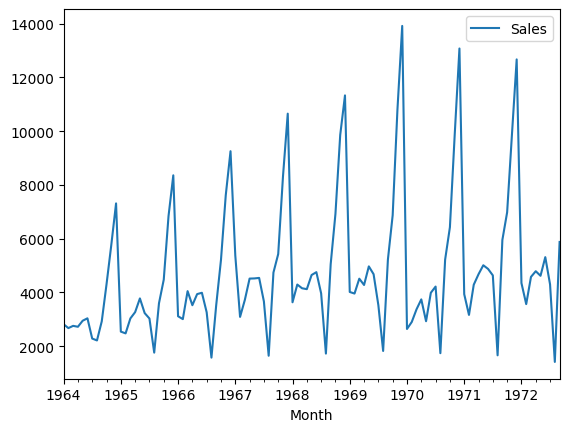

In [14]:
df.plot()

In [17]:
## testing for stationarity
%pip install statsmodels
from statsmodels.tsa.stattools import adfuller

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.6 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/9.5 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.6 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.6 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.6 MB/s eta 0:00:05
   ---------------- ----------------------- 3.9/9.5 MB 1.7 MB/s eta 0:00:04
   ------------------ --------------------- 4.5/9.5 MB 1.8 MB/s eta 0:00:03
   -----------------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
test_result=adfuller(df['Sales'])

In [21]:
## H0 : It is non stationary
## H1 : It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels=['ADF Test Statistic','p-value','#Lags Used','Number of Observations used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value))
    if result[1] <= 0.05:
        print('strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is statinry')
    else:
        print('weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary')

# Differencing

In [23]:
df['Sales First Difference']=df['Sales']-df['Sales'].shift(1)